# 04. SDOH Segment Analysis

## Objective

This notebook evaluates whether the Diabetes Peer Support intervention performed differently across member subgroups.

The main questions are:

1. Did Diabetes Peer Support improve diabetes testing compliance across SDOH risk groups?
2. Were results different for members with specific barriers such as food insecurity, transportation barriers, financial barriers, or housing instability?
3. Did members with lower baseline engagement respond differently to peer support?

Important caution:

Segment analysis is exploratory. The original randomized experiment compares Diabetes Peer Support against Standard Outreach overall. Subgroup comparisons can be useful for targeting and business strategy, but they should be interpreted carefully because smaller sample sizes can produce noisier results.

## 1. Imports 

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# Define the project-relative path to the synthetic A/B testing dataset
DATA_PATH = Path("../data/raw/mock_diabetes_peer_support_ab_test.csv")

# Load the generated dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Confirm the number of rows and columns
df.shape

(4000, 33)

## 3. Preview Dataset

In [3]:
df.head()

,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         4000 non-null   int64  
 1   age                               4000 non-null   int64  
 2   gender                            4000 non-null   str    
 3   region                            4000 non-null   str    
 4   plan_type                         4000 non-null   str    
 5   target_population_flag            4000 non-null   int64  
 6   diabetes_severity_score           4000 non-null   float64
 7   chronic_condition_count           4000 non-null   int64  
 8   baseline_engagement_score         3749 non-null   float64
 9   health_literacy_score             3706 non-null   float64
 10  prior_testing_compliance_rate     4000 non-null   float64
 11  sdoh_risk_score                   4000 non-null   float64
 12  food_insecurity  

In [5]:
df["experiment_group"].value_counts()

experiment_group
Diabetes Peer Support    2078
Standard Outreach        1922
Name: count, dtype: int64

## 4. Confirm Segment Variables

In [6]:
# Define SDOH barrier columns used for subgroup analysis
sdoh_barrier_cols = [
    "food_insecurity",
    "transportation_barrier",
    "financial_barrier",
    "housing_instability"
]

# Review the distribution of each SDOH barrier
df[sdoh_barrier_cols].mean().sort_values(ascending=False)

financial_barrier         0.39000
food_insecurity           0.35000
transportation_barrier    0.29425
housing_instability       0.21700
dtype: float64

In [7]:
# Review the numeric SDOH risk score distribution
df["sdoh_risk_score"].describe()

count    4000.000000
mean        0.330597
std         0.241925
min         0.000000
25%         0.140000
50%         0.304000
75%         0.508250
max         1.000000
Name: sdoh_risk_score, dtype: float64

## 5. Create SDOH Risk Groups

The dataset includes a continuous SDOH risk score.

For business interpretation, we convert this score into three groups:

- Low SDOH risk
- Medium SDOH risk
- High SDOH risk

This makes it easier to compare whether the peer-support intervention had different results among members with different levels of social risk.

In [8]:
# Check whether SDOH risk score supports quantile splitting
sdoh_unique_count = df["sdoh_risk_score"].nunique()
sdoh_total_count = df["sdoh_risk_score"].count()

print(f"Unique SDOH risk score values: {sdoh_unique_count}")
print(f"Total non-missing SDOH risk score values: {sdoh_total_count}")
print(f"Unique value ratio: {sdoh_unique_count / sdoh_total_count:.3f}")

Unique SDOH risk score values: 855
Total non-missing SDOH risk score values: 4000
Unique value ratio: 0.214


In [9]:
# Create SDOH risk groups using tertiles of the SDOH risk score
df["sdoh_risk_group"] = pd.qcut(
    df["sdoh_risk_score"],
    q=3,
    labels=["Low SDOH Risk", "Medium SDOH Risk", "High SDOH Risk"]
)

df["sdoh_risk_group"].value_counts()

sdoh_risk_group
Low SDOH Risk       1340
High SDOH Risk      1331
Medium SDOH Risk    1329
Name: count, dtype: int64

## 6. Create Baseline Engagement Groups

In [10]:
# Check missingness before creating engagement segments
baseline_engagement_missing_rate = df["baseline_engagement_score"].isna().mean() * 100

print(f"Baseline engagement missing rate: {baseline_engagement_missing_rate:.1f}%")

Baseline engagement missing rate: 6.3%


Members with missing baseline engagement scores remain missing after engagement segmentation. This is acceptable for descriptive subgroup analysis, but engagement-segment findings should be interpreted with awareness that not all members are included in these groups.

In [11]:
# Check whether baseline engagement score supports quantile splitting
engagement_unique_count = df["baseline_engagement_score"].nunique()
engagement_total_count = df["baseline_engagement_score"].count()

print(f"Unique baseline engagement score values: {engagement_unique_count}")
print(f"Total non-missing baseline engagement score values: {engagement_total_count}")
print(f"Unique value ratio: {engagement_unique_count / engagement_total_count:.3f}")

Unique baseline engagement score values: 870
Total non-missing baseline engagement score values: 3749
Unique value ratio: 0.232


In [12]:
# Create baseline engagement groups using tertiles of the engagement score
df["baseline_engagement_group"] = pd.qcut(
    df["baseline_engagement_score"],
    q=3,
    labels=["Low Engagement", "Medium Engagement", "High Engagement"]
)

# Confirm group sizes after segmentation
df["baseline_engagement_group"].value_counts(dropna=False)

baseline_engagement_group
Low Engagement       1251
Medium Engagement    1249
High Engagement      1249
NaN                   251
Name: count, dtype: int64

## 7. Define Segment Analysis Function

In [13]:
# Create a reusable function to compare treatment and control outcomes within each segment
def summarize_segment_effect(data, segment_col):
    segment_summary = (
        data
        .groupby([segment_col, "experiment_group"], observed=True)
        .agg(
            members=("member_id", "count"),
            avg_compliance_rate=("diabetes_testing_compliance_rate", "mean"),
            binary_compliance_rate=("diabetes_testing_compliant", "mean")
        )
        .reset_index()
    )

    # Pivot treatment and control results into one row per segment
    pivot_summary = segment_summary.pivot(
        index=segment_col,
        columns="experiment_group",
        values=["members", "avg_compliance_rate", "binary_compliance_rate"]
    )

    # Flatten multi-level column names for easier reading
    pivot_summary.columns = [
        f"{metric}_{group}".replace(" ", "_").lower()
        for metric, group in pivot_summary.columns
    ]

    pivot_summary = pivot_summary.reset_index()

    # Calculate absolute lift for average compliance rate
    pivot_summary["avg_compliance_absolute_lift"] = (
        pivot_summary["avg_compliance_rate_diabetes_peer_support"] -
        pivot_summary["avg_compliance_rate_standard_outreach"]
    )

    # Calculate absolute lift for binary compliance rate
    pivot_summary["binary_compliance_absolute_lift"] = (
        pivot_summary["binary_compliance_rate_diabetes_peer_support"] -
        pivot_summary["binary_compliance_rate_standard_outreach"]
    )

    return pivot_summary

## 8. SDOH Risk Group Segment Results

In [14]:
# Compare treatment and control outcomes by SDOH risk group
sdoh_risk_summary = summarize_segment_effect(df, "sdoh_risk_group")

# Round rates for cleaner reporting
sdoh_risk_summary = sdoh_risk_summary.round(3)

sdoh_risk_summary

,sdoh_risk_group,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,Low SDOH Risk,693.0,647.0,0.791,0.750,0.485,0.431,0.041,0.054
1,Medium SDOH Risk,693.0,636.0,0.768,0.741,0.462,0.421,0.028,0.040
2,High SDOH Risk,692.0,639.0,0.674,0.646,0.322,0.274,0.028,0.048


## 9. SDOH Risk Group Visualization

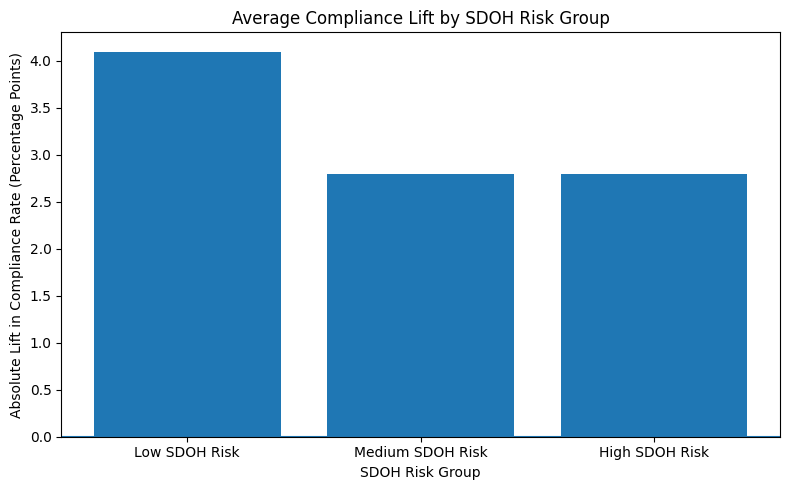

In [15]:
# Visualize average compliance lift by SDOH risk group
plt.figure(figsize=(8, 5))
plt.bar(
    sdoh_risk_summary["sdoh_risk_group"].astype(str),
    sdoh_risk_summary["avg_compliance_absolute_lift"] * 100
)

plt.title("Average Compliance Lift by SDOH Risk Group")
plt.xlabel("SDOH Risk Group")
plt.ylabel("Absolute Lift in Compliance Rate (Percentage Points)")
plt.axhline(0)
plt.tight_layout()
plt.show()

## 10. SDOH Barrier Segment Analysis

Next, we compare treatment and control outcomes for members with specific barriers.

The barriers reviewed are:

- Food insecurity
- Transportation barrier
- Financial barrier
- Housing instability

This helps identify whether peer support may be especially useful for members facing practical or social barriers to diabetes testing.

## 11. Food Insecurity Segment

In [16]:
# Compare treatment and control outcomes by food insecurity status
food_insecurity_summary = summarize_segment_effect(df, "food_insecurity")

food_insecurity_summary = food_insecurity_summary.round(3)

food_insecurity_summary

,food_insecurity,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,0,1345.0,1255.0,0.763,0.733,0.446,0.406,0.031,0.041
1,1,733.0,667.0,0.710,0.675,0.381,0.319,0.035,0.061


## 12. Transportation Barrier Segment

In [17]:
# Compare treatment and control outcomes by transportation barrier status
transportation_summary = summarize_segment_effect(df, "transportation_barrier")

transportation_summary = transportation_summary.round(3)

transportation_summary

,transportation_barrier,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,0,1460.0,1363.0,0.763,0.731,0.454,0.403,0.033,0.051
1,1,618.0,559.0,0.701,0.669,0.350,0.309,0.032,0.040


## 13. Financial Barrier Segment

In [18]:
# Compare treatment and control outcomes by financial barrier status
financial_summary = summarize_segment_effect(df, "financial_barrier")

financial_summary = financial_summary.round(3)

financial_summary

,financial_barrier,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,0,1275.0,1165.0,0.76,0.739,0.442,0.421,0.021,0.021
1,1,803.0,757.0,0.72,0.672,0.392,0.305,0.048,0.087


## 14. Housing Instability Segment

In [19]:
# Compare treatment and control outcomes by housing instability status
housing_summary = summarize_segment_effect(df, "housing_instability")

housing_summary = housing_summary.round(3)

housing_summary

,housing_instability,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,0,1615.0,1517.0,0.750,0.716,0.427,0.383,0.034,0.044
1,1,463.0,405.0,0.726,0.699,0.408,0.348,0.028,0.060


## 15. Combine Barrier Results

In [20]:
# Create a helper function for binary barrier summaries
def summarize_binary_barrier(data, barrier_col, barrier_label):
    summary = summarize_segment_effect(data, barrier_col)

    # Keep only members with the barrier present
    barrier_present = summary[summary[barrier_col] == 1].copy()

    # Add a readable barrier name
    barrier_present["barrier"] = barrier_label

    return barrier_present

In [21]:
# Combine treatment effects among members with each SDOH barrier
barrier_lift_summary = pd.concat(
    [
        summarize_binary_barrier(df, "food_insecurity", "Food Insecurity"),
        summarize_binary_barrier(df, "transportation_barrier", "Transportation Barrier"),
        summarize_binary_barrier(df, "financial_barrier", "Financial Barrier"),
        summarize_binary_barrier(df, "housing_instability", "Housing Instability")
    ],
    ignore_index=True
)

# Select the most important columns for business interpretation
barrier_lift_summary = barrier_lift_summary[
    [
        "barrier",
        "members_standard_outreach",
        "members_diabetes_peer_support",
        "avg_compliance_rate_standard_outreach",
        "avg_compliance_rate_diabetes_peer_support",
        "avg_compliance_absolute_lift",
        "binary_compliance_absolute_lift"
    ]
]

# Round rates for cleaner reporting
barrier_lift_summary = barrier_lift_summary.round(3)

barrier_lift_summary

,barrier,members_standard_outreach,members_diabetes_peer_support,avg_compliance_rate_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,Food Insecurity,667.0,733.0,0.675,0.710,0.035,0.061
1,Transportation Barrier,559.0,618.0,0.669,0.701,0.032,0.040
2,Financial Barrier,757.0,803.0,0.672,0.720,0.048,0.087
3,Housing Instability,405.0,463.0,0.699,0.726,0.028,0.060


## 16. Barrier Lift Visualization

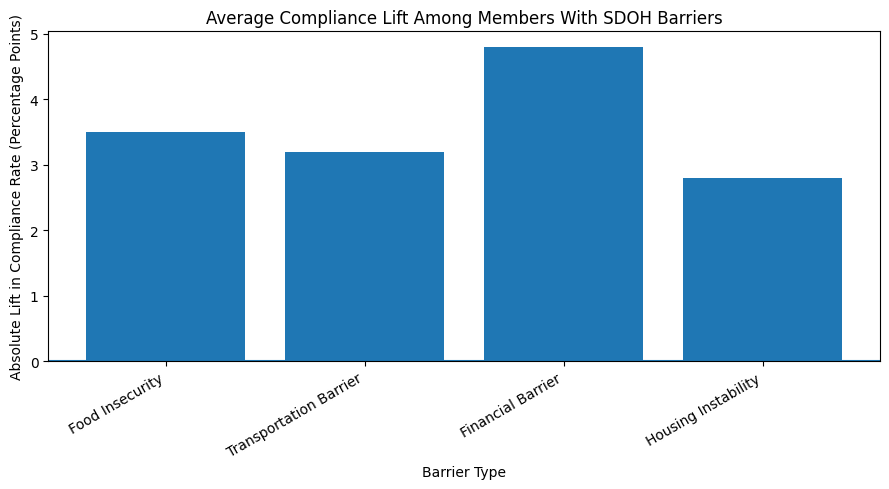

In [22]:
# Visualize average compliance lift among members with each SDOH barrier
plt.figure(figsize=(9, 5))
plt.bar(
    barrier_lift_summary["barrier"],
    barrier_lift_summary["avg_compliance_absolute_lift"] * 100
)

plt.title("Average Compliance Lift Among Members With SDOH Barriers")
plt.xlabel("Barrier Type")
plt.ylabel("Absolute Lift in Compliance Rate (Percentage Points)")
plt.axhline(0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 17. Baseline Engagement Segment Results

In [23]:
# Compare treatment and control outcomes by baseline engagement group
engagement_summary = summarize_segment_effect(df, "baseline_engagement_group")

engagement_summary = engagement_summary.round(3)

engagement_summary

,baseline_engagement_group,members_diabetes_peer_support,members_standard_outreach,avg_compliance_rate_diabetes_peer_support,avg_compliance_rate_standard_outreach,binary_compliance_rate_diabetes_peer_support,binary_compliance_rate_standard_outreach,avg_compliance_absolute_lift,binary_compliance_absolute_lift
0,Low Engagement,626.0,625.0,0.662,0.644,0.284,0.264,0.018,0.020
1,Medium Engagement,648.0,601.0,0.773,0.732,0.461,0.413,0.042,0.049
2,High Engagement,674.0,575.0,0.801,0.772,0.524,0.461,0.029,0.063


## 18. Baseline Engagement Visualization

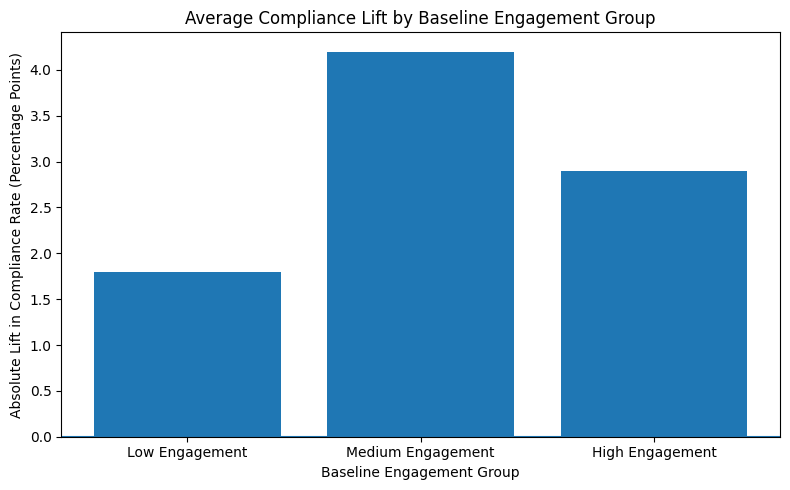

In [24]:
# Visualize average compliance lift by baseline engagement group
plt.figure(figsize=(8, 5))
plt.bar(
    engagement_summary["baseline_engagement_group"].astype(str),
    engagement_summary["avg_compliance_absolute_lift"] * 100
)

plt.title("Average Compliance Lift by Baseline Engagement Group")
plt.xlabel("Baseline Engagement Group")
plt.ylabel("Absolute Lift in Compliance Rate (Percentage Points)")
plt.axhline(0)
plt.tight_layout()
plt.show()

## 19. Sample Size Review

Segment analysis can become unstable when subgroup sizes are small.

Before making business recommendations, we should review how many members are included in each segment. Larger groups provide more reliable directional evidence. Smaller groups should be interpreted as exploratory only.

## 20. Segment Sample Sizes

In [25]:
# Review sample sizes by SDOH risk group and experiment group
pd.crosstab(df["sdoh_risk_group"], df["experiment_group"])

experiment_group,Diabetes Peer Support,Standard Outreach
sdoh_risk_group,,
Low SDOH Risk,693,647
Medium SDOH Risk,693,636
High SDOH Risk,692,639


In [26]:
# Review sample sizes by baseline engagement group and experiment group
pd.crosstab(df["baseline_engagement_group"], df["experiment_group"])

experiment_group,Diabetes Peer Support,Standard Outreach
baseline_engagement_group,,
Low Engagement,626,625
Medium Engagement,648,601
High Engagement,674,575


In [27]:
# Review sample sizes for each binary SDOH barrier by experiment group
for barrier in sdoh_barrier_cols:
    print(f"\n{barrier}")
    display(pd.crosstab(df[barrier], df["experiment_group"]))


food_insecurity


experiment_group,Diabetes Peer Support,Standard Outreach
food_insecurity,,
0,1345,1255
1,733,667



transportation_barrier


experiment_group,Diabetes Peer Support,Standard Outreach
transportation_barrier,,
0,1460,1363
1,618,559



financial_barrier


experiment_group,Diabetes Peer Support,Standard Outreach
financial_barrier,,
0,1275,1165
1,803,757



housing_instability


experiment_group,Diabetes Peer Support,Standard Outreach
housing_instability,,
0,1615,1517
1,463,405


## 21. Segment Findings

The SDOH segment analysis showed that Diabetes Peer Support improved diabetes testing compliance across all SDOH risk groups.

Observed average compliance lift by SDOH risk group:

- Low SDOH Risk: +4.1 percentage points
- Medium SDOH Risk: +2.8 percentage points
- High SDOH Risk: +2.8 percentage points

Observed binary compliance lift by SDOH risk group:

- Low SDOH Risk: +5.4 percentage points
- Medium SDOH Risk: +4.0 percentage points
- High SDOH Risk: +4.8 percentage points

Among members with specific SDOH barriers, the largest observed binary compliance lift appeared among members with financial barriers.

Observed binary compliance lift among members with each barrier:

- Food insecurity: +6.1 percentage points
- Transportation barrier: +4.0 percentage points
- Financial barrier: +8.7 percentage points
- Housing instability: +6.0 percentage points

The baseline engagement analysis showed that binary compliance lift was highest among members with high baseline engagement.

Observed binary compliance lift by baseline engagement group:

- Low Engagement: +2.0 percentage points
- Medium Engagement: +4.9 percentage points
- High Engagement: +6.3 percentage points

These findings should be interpreted as exploratory subgroup results. The notebook compares observed subgroup differences, but it does not prove that the treatment effect is statistically different across segments.

Important subgroup-analysis caution:

These segment comparisons are exploratory. Because multiple segments are reviewed, individual subgroup differences should not be overinterpreted as confirmed heterogeneous treatment effects.

To formally test whether Diabetes Peer Support performed differently across SDOH or engagement groups, a later adjusted model should include treatment-by-segment interaction terms.

## 22. Business Interpretation

This segment analysis helps identify where Diabetes Peer Support may have the highest operational value.

The SDOH risk-group results suggest that the program showed positive observed lift across low, medium, and high SDOH risk groups. The lift was not limited to only one risk tier.

Among specific SDOH barriers, the largest observed binary compliance lift appeared among members with financial barriers. This may suggest that peer-support outreach could be especially useful for members facing cost-related or resource-related challenges, although this finding should be treated as exploratory.

The baseline engagement results showed the largest observed binary compliance lift among members with high baseline engagement. This suggests that members who were already more engaged may have been better positioned to respond to the peer-support intervention.

These findings should guide future targeting and program design, not replace the overall intent-to-treat A/B result.

Because this notebook reviews multiple segments, the results should be interpreted as exploratory subgroup evidence rather than confirmed heterogeneous treatment effects.

## 23. Summary

This notebook evaluated whether Diabetes Peer Support performed differently across SDOH and engagement segments.

Key takeaways:

1. SDOH risk groups were created from the continuous SDOH risk score.
2. Treatment and control outcomes were compared within each SDOH risk group.
3. Specific barriers such as food insecurity, transportation barriers, financial barriers, and housing instability were reviewed.
4. Baseline engagement segments were analyzed to identify whether lower-engagement members responded differently.
5. Segment-level lift was calculated using both average compliance rate and binary compliance rate.
6. Sample sizes were reviewed to avoid overinterpreting small subgroups.
7. Segment findings were interpreted as exploratory and business-oriented, not definitive causal subgroup proof.

The main randomized result remains the overall intent-to-treat A/B comparison from Notebook 02. This notebook supports targeting strategy and future program design.
